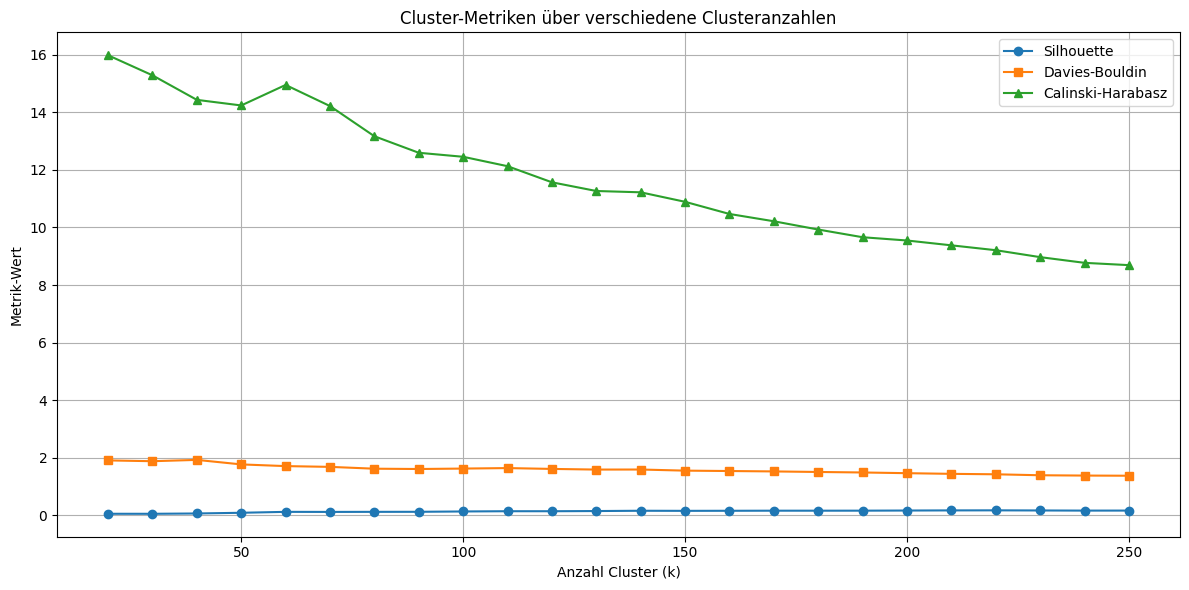


✅ Beste Clusteranzahl (kombiniert bewertet): k=220

🔎 Top TF-IDF Keywords pro Cluster:

📁 Cluster 0 (n=14):
Top Keywords: 89b, hgb, nach, handelsvertreterausgleichs, berechnung

📁 Cluster 1 (n=55):
Top Keywords: die, der, welche, eines, bedeutung

📁 Cluster 2 (n=7):
Top Keywords: geräuschemissionen, schallschutzstandard, mietwohnung, von, zumutbarkeitsgrenze

📁 Cluster 3 (n=4):
Top Keywords: bedeutung, der, erfüllungsinteresse, verwirkung, regelverjährung

📁 Cluster 4 (n=2):
Top Keywords: 952, herausgabeanspruch, besitz, fahrzeugs, betrieben

📁 Cluster 5 (n=5):
Top Keywords: vob, vertrags, als, schriftformerfordernis, ganzes

📁 Cluster 6 (n=56):
Top Keywords: käufer, kaufsache, der, verkäufer, ein

📁 Cluster 7 (n=36):
Top Keywords: vergütung, die, einem, übliche, mit

📁 Cluster 8 (n=6):
Top Keywords: arglistigen, täuschungen, täuschung, sie, nutzungsänderungen

📁 Cluster 9 (n=102):
Top Keywords: die, der, welche, klage, wenn

📁 Cluster 10 (n=47):
Top Keywords: versicherungsnehmer, auf

In [5]:
import re
import json
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sentence_transformers import SentenceTransformer
from kneed import KneeLocator
from transformers import pipeline
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
import seaborn as sns
from sklearn.manifold import TSNE

# Load questions
cq_path = "competency_questions_output/competency_questions_200_documents.txt"
with open(cq_path, "r", encoding="utf-8") as f:
    content = f.read()
questions = re.findall(r'\*\*Frage:\*\*\s*(.+?)(?=\n\*\*Quelle:\*\*|\n\d+\.\Z)', content, re.DOTALL)
questions = list(dict.fromkeys(questions))

# Embeddings
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = model.encode(questions)
X_emb_dense = squareform(pdist(embeddings, metric="cosine"))

# Auto-Tuning Clusteranzahl mit kombinierter Metrikbewertung
sil_scores, db_scores, ch_scores, ks = [], [], [], []
k_range = range(20, 251, 10)
all_labels = []

for k in k_range:
    clustering = AgglomerativeClustering(metric='precomputed', linkage='average', n_clusters=k)
    labels = clustering.fit_predict(X_emb_dense)
    sil = silhouette_score(X_emb_dense, labels, metric="precomputed")
    db = davies_bouldin_score(embeddings, labels)
    ch = calinski_harabasz_score(embeddings, labels)

    ks.append(k)
    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)
    all_labels.append(labels)

# Normalisieren & kombinierte Bewertung
sil_norm = (sil_scores - np.mean(sil_scores)) / np.std(sil_scores)
db_norm = (db_scores - np.mean(db_scores)) / np.std(db_scores)
ch_norm = (ch_scores - np.mean(ch_scores)) / np.std(ch_scores)
combined_scores = sil_norm + ch_norm - db_norm

best_idx = np.argmax(combined_scores)
best_k = ks[best_idx]
best_labels = all_labels[best_idx]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(ks, sil_scores, marker='o', label='Silhouette')
plt.plot(ks, db_scores, marker='s', label='Davies-Bouldin')
plt.plot(ks, ch_scores, marker='^', label='Calinski-Harabasz')
plt.title("Cluster-Metriken über verschiedene Clusteranzahlen")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Metrik-Wert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\n✅ Beste Clusteranzahl (kombiniert bewertet): k={best_k}")

# TF-IDF for keywords
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(questions)
feature_names = np.array(vectorizer.get_feature_names_out())

# Keywords per cluster basierend auf best_labels
print("\n🔎 Top TF-IDF Keywords pro Cluster:")
for cluster_id in sorted(set(best_labels)):
    cluster_indices = [i for i, label in enumerate(best_labels) if label == cluster_id]
    cluster_texts = [questions[i] for i in cluster_indices]
    cluster_matrix = vectorizer.transform(cluster_texts).mean(axis=0).A1
    top_keywords = feature_names[cluster_matrix.argsort()[-5:][::-1]]
    print(f"\n📁 Cluster {cluster_id} (n={len(cluster_indices)}):")
    print("Top Keywords:", ", ".join(top_keywords))